
================ MENU PRINCIPAL ================
1) Modo Normalizacion Interactivo
2) Modo Normalizacion Automático
3) Modo Machin Learning
0) Salir del programa


Seleccione opción >>  1



================ MENU INTERACTIVO ==============
1) Cargar Dataset
2) Limpiar Dataset
3) Normalizar Dataset
4) Calibración Probabilística
5) Exportar Dataset Limpio
6) Seleccionar rutas carpetas
7) Mostrar rutas actuales
8) Inferencia desde Pipeline Exportado
9) Salir


Seleccione opción >>  1


Cargando dataset...
Dataset cargado.

================ MENU INTERACTIVO ==============
1) Cargar Dataset
2) Limpiar Dataset
3) Normalizar Dataset
4) Calibración Probabilística
5) Exportar Dataset Limpio
6) Seleccionar rutas carpetas
7) Mostrar rutas actuales
8) Inferencia desde Pipeline Exportado
9) Salir


...


==========Calibración Probabilística=============
Seleccione el método de calibración:
1) sin calibración
2) Platt (Sigmoid) [Recomendado dataset pequeño]
3) Isotonic        [Recomendado dataset grande]
4) Auto            [Deja que el sistema elija]
0) Atras
Seleccione opción >> 

 4



================ Ranking Mode =================
1) Tecnico  (AUC > BalancedAcc > F1)
2) Clinico  (Recall > Specificity > Precision)
3) Mixto    (AUC > Recall > BalancedAcc > F1)
0) Atras
Seleccione opción >> 

 2


Split aplicado: Stratified Split (70/15/15)

[Cal] Entrenando + calibrando (interactive) ...
[Cal] Modelo: LR
      threshold_clinico (Rec>=0.98) -> 0.494
   -> AUC=1.0000 | BalAcc=0.9844 | F1=0.9841 | Prec=1.0000 | Rec=0.9688 | Spec=1.0000
[Cal] Modelo: SVM
      threshold_clinico (Rec>=0.98) -> 0.290
   -> AUC=0.9994 | BalAcc=0.9688 | F1=0.9677 | Prec=1.0000 | Rec=0.9375 | Spec=1.0000
[Cal] Modelo: RF
      threshold_clinico (Rec>=0.98) -> 0.016
   -> AUC=0.9977 | BalAcc=0.9688 | F1=0.9677 | Prec=1.0000 | Rec=0.9375 | Spec=1.0000

[Cal] Mejor modelo: LR | modo_rank=clinico
[Panel] Export OK -> PNG: C:/Users/j2rod/Documents/MASTER IA/Proyecto/breast+cancer+wisconsin+diagnostic/models/calibracion_interactiva_20260119_012508\panel_ranking_interactivo_20260119_012508.png
[Panel] Export OK -> PDF: C:/Users/j2rod/Documents/MASTER IA/Proyecto/breast+cancer+wisconsin+diagnostic/models/calibracion_interactiva_20260119_012508\panel_ranking_interactivo_20260119_012508.pdf


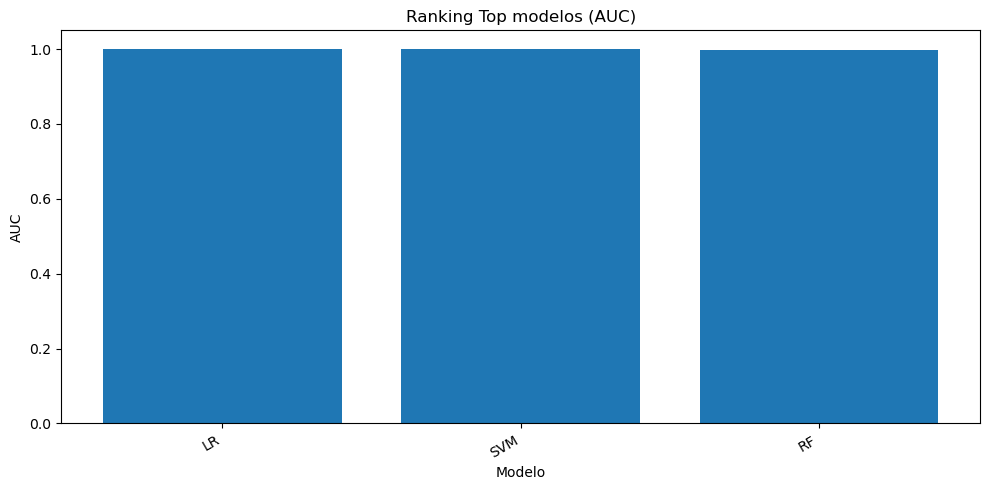

[Cal] Export OK -> C:/Users/j2rod/Documents/MASTER IA/Proyecto/breast+cancer+wisconsin+diagnostic/models/calibracion_interactiva_20260119_012508

============== Inferencia Clínica ==============
¿Ejecutar inferencia ahora con threshold clínico? [s/n]
0) Atras


Seleccione opción >>  s


[Inferencia] OK -> C:/Users/j2rod/Documents/MASTER IA/Proyecto/breast+cancer+wisconsin+diagnostic/models/calibracion_interactiva_20260119_012508\inferencia_20260119_012513.csv

================ MENU INTERACTIVO ==============
1) Cargar Dataset
2) Limpiar Dataset
3) Normalizar Dataset
4) Calibración Probabilística
5) Exportar Dataset Limpio
6) Seleccionar rutas carpetas
7) Mostrar rutas actuales
8) Inferencia desde Pipeline Exportado
9) Salir


Seleccione opción >>  8



========== Inferencia desde Pipeline ==========
Ingrese ruta carpeta pipeline (donde está modelo.joblib):


>>  z


¿Usar threshold clínico si existe threshold.json? [s/n]


>>  s


[PipelineLoad] FAIL: ruta no existe -> z
[InferPipeline] FAIL.

================ MENU INTERACTIVO ==============
1) Cargar Dataset
2) Limpiar Dataset
3) Normalizar Dataset
4) Calibración Probabilística
5) Exportar Dataset Limpio
6) Seleccionar rutas carpetas
7) Mostrar rutas actuales
8) Inferencia desde Pipeline Exportado
9) Salir


In [ ]:
# ======================================================
# ----------- IMPORTS GLOBALES DEL PROYECTO ------------
# ======================================================

import os
import json
import pandas as pd
import numpy as np

# Visualización (para EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import recall_score, f1_score, roc_auc_score, balanced_accuracy_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, confusion_matrix


import joblib

# ======================================================
# -------------------- CONFIGURACIÓN -------------------
# ======================================================

# Rutas por defecto dentro del proyecto
# NOTA: Estas rutas se pueden modificar según el entorno, por ahora quedan dentro del proyecto.
# En modo interactivo y automático el usuario podrá usar estas por defecto o introducir nuevas.
RUTA_RAW_DEFAULT = r"C:/Users/j2rod\Documents/MASTER IA/Proyecto/breast+cancer+wisconsin+diagnostic/"
RUTA_CLEAN_DEFAULT = r"C:/Users/j2rod\Documents/MASTER IA/Proyecto/breast+cancer+wisconsin+diagnostic/data_clean/"
RUTA_NORM_DEFAULT = r"C:/Users/j2rod\Documents/MASTER IA/Proyecto/breast+cancer+wisconsin+diagnostic/data_norm/"
RUTA_LOGS_DEFAULT = r"C:/Users/j2rod\Documents/MASTER IA/Proyecto/breast+cancer+wisconsin+diagnostic/logs/"
RUTA_ML_DEFAULT = r"C:/Users/j2rod/Documents/MASTER IA/Proyecto/breast+cancer+wisconsin+diagnostic/models/"

# Archivo por defecto para probar
ARCHIVO_DATASET_DEFAULT = "wdbc.data"  # como acordamos, dataset sucio sin cabecera

# Crear carpetas por defecto si no existen
for carpeta in [RUTA_RAW_DEFAULT, RUTA_CLEAN_DEFAULT, RUTA_NORM_DEFAULT, RUTA_LOGS_DEFAULT,RUTA_ML_DEFAULT]:
    os.makedirs(carpeta, exist_ok=True)
   # os.makedirs(RUTA_ML_DEFAULT, exist_ok=True)


# ======================================================
# -------------------- FUNCIONES UTILES ----------------
# ======================================================

def timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def guardar_log(evento, detalles):
    """Guarda trazabilidad en logs.json con timestamp."""
    log_entry = {
        "timestamp": datetime.now().isoformat(),
        "evento": evento,
        "detalles": detalles
    }
    ruta_log = os.path.join(RUTA_LOGS_DEFAULT, "logs.json")

    if os.path.exists(ruta_log):
        with open(ruta_log, "r", encoding="utf-8") as f:
            data = json.load(f)
    else:
        data = []

    data.append(log_entry)

    with open(ruta_log, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)
def _safe_json_dump(obj, path):
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(obj, f, indent=4, ensure_ascii=False)
        return True
    except Exception as e:
        print(f"[RunLog] FAIL writing json -> {path} | err={e}")
        return False


def _safe_json_load(path, default=None):
    if default is None:
        default = []
    try:
        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        return default
    except Exception:
        return default

def build_run_payload(
    run_type,
    ruta_export,
    dataset_path=None,
    metodo_norm=None,
    metodo_cal=None,
    modo_rank=None,
    ranking=None,
    threshold_info=None,
    rutas_panel=None,
    extra=None
):
    """
    run_type: "auto" | "interactive" | "ml_pipeline" | "cal_interactive" | etc.
    """
    payload = {
        "run_id": f"{run_type}_{timestamp()}",
        "timestamp": datetime.now().isoformat(),
        "run_type": run_type,
        "ruta_export": ruta_export,
        "dataset_path": dataset_path,
        "metodo_norm": metodo_norm,
        "metodo_cal": metodo_cal,
        "modo_rank": modo_rank,
        "artifacts": {
            "ranking_json": os.path.join(ruta_export, "ranking.json") if ruta_export else None,
            "threshold_json": os.path.join(ruta_export, "threshold.json") if ruta_export else None,
            "panel_pdf": (rutas_panel.get("pdf") if rutas_panel else None),
            "panel_png": (rutas_panel.get("png") if rutas_panel else None),
        },
        "ranking_top": None,
        "threshold_info": threshold_info,
        "extra": extra or {}
        }
        # snapshot compacto del top ranking (para auditoría rápida sin abrir ranking.json)
    if ranking is not None and isinstance(ranking, list) and len(ranking) > 0:
        top = ranking[0]
        payload["ranking_top"] = {
            "modelo": top.get("modelo"),
            "normalizacion": top.get("normalizacion"),
            "metricas": top.get("metricas", {})
        }

    return payload


def guardar_run_structured(ruta_export, run_payload):
    """
    Crea run.json dentro de ruta_export
    y además actualiza índice global logs/runs_index.json
    """
    if ruta_export is None or ruta_export.strip() == "":
        print("[RunLog] FAIL: ruta_export vacía.")
        return False

    os.makedirs(ruta_export, exist_ok=True)

    # 1) run.json dentro de la carpeta del export
    run_path = os.path.join(ruta_export, "run.json")
    ok_run = _safe_json_dump(run_payload, run_path)

    # 2) índice global
    os.makedirs(RUTA_LOGS_DEFAULT, exist_ok=True)
    idx_path = os.path.join(RUTA_LOGS_DEFAULT, "runs_index.json")
    idx = _safe_json_load(idx_path, default=[])

    idx.append({
        "run_id": run_payload.get("run_id"),
        "timestamp": run_payload.get("timestamp"),
        "run_type": run_payload.get("run_type"),
        "ruta_export": ruta_export,
        "run_json": run_path
    })

    ok_idx = _safe_json_dump(idx, idx_path)

    if ok_run and ok_idx:
        print(f"[RunLog] OK -> run.json + runs_index.json")
        return True

    return False
    
def pedir_ruta(msg, default_path):
    
    #Si el usuario deja vacío -> usa default_path.
    print(msg)
    val = input(">> ").strip()
    if val == "":
        return default_path
    return val
    
# ======================================================
# -------------------- CARGA DATASET --------------------
# ======================================================

def cargar_dataset(ruta_archivo):
    """
    Carga el dataset original sin cabeceras y devuelve DataFrame.
    """
    # -------------------------------------------
    #         Cargar Dataset Original            
    # -------------------------------------------
    try:
        df = pd.read_csv(ruta_archivo, header=None)
        guardar_log("carga_dataset", {"ruta": ruta_archivo, "filas": len(df)})
        return df
    except Exception as e:
        print("Error cargando dataset:", e)
        return None


# ======================================================
# -------------------- LIMPIEZA DATASET ----------------
# ======================================================

def limpiar_dataset(df):
    """
    Limpieza básica:
     - Renombrar columnas wdbc
     - Transformar diagnosis M->1 B->0
     - Eliminar duplicados
     - Eliminar vacíos / NaN
    """
    # -------------------------------------------
    #     Iniciando Limpieza del Dataset         
    # -------------------------------------------

    print("[Clean] Iniciando Limpieza del Dataset")
    
    # Aclaración: wdbc.data tiene estructura:
    # Col0: ID, Col1: diagnosis (M/B), resto variables numéricas
    # No viene cabecera
    columnas = ["ID", "diagnostico"] + [f"var_{i}" for i in range(1, 31)]
    df.columns = columnas
   
    # Transformar variables maligno/benigno
    print("[Clean] Transformando etiquetas M/B a 1/0 ...", end=" ")
    df["diagnostico"] = df["diagnostico"].map({"M": 1, "B": 0})
    print("OK")

    # Eliminar duplicados
    n_duplicados = df.duplicated().sum()   # contar duplicados
    print("[Clean] Eliminando duplicados ...", end=" ")
    df = df.drop_duplicates()
    print("OK" if n_duplicados >= 0 else "FAIL")
    
    # Eliminar filas vacías o nulas
    n_nulos = df.isna().sum().sum()         # contar nulos
    print("[Clean] Eliminando filas nulas ...", end=" ")
    #df = df.dropna()
    df = df.dropna(how="any", axis=0) # verifia que no tenga vacios
    print("OK" if n_nulos >= 0 else "FAIL")

    # Mostrar dimensiones
    print(f"[Clean] Dimensiones originales: {(len(df)+n_duplicados+n_nulos, len(df.columns))}")
    print(f"[Clean] Dimensiones finales: {(len(df), len(df.columns))}")


    # -------------------------------------------
    #      Fin de Limpieza del Dataset           
    # -------------------------------------------

    guardar_log("limpieza_dataset", {
        "Filas_inicial": int(len(df) + n_duplicados + n_nulos),
        "Filas_final": int(len(df)),
        "Duplicados_eliminados": int(n_duplicados),
        "Nulos_eliminados": int(n_nulos),
        })
    return df


# ======================================================
# ------------------- EXPORTAR DATA --------------------
# ======================================================

def exportar_clean(df, ruta_destino):
    """
    Exporta dataset limpio a CSV y Excel con timestamp.
    """
    # -------------------------------------------
    #   Guardando Base de Datos Limpia Exportada 
    # -------------------------------------------
    os.makedirs(ruta_destino, exist_ok=True)
    ts = timestamp()

    ruta_csv = os.path.join(ruta_destino, f"dataset_limpio_{ts}.csv")
    ruta_xlsx = os.path.join(ruta_destino, f"dataset_limpio_{ts}.xlsx")

    df.to_csv(ruta_csv, index=False)
    df.to_excel(ruta_xlsx, index=False)

    guardar_log("export_clean", {"csv": ruta_csv, "xlsx": ruta_xlsx})
    print("[Dataset] "f"Dataset limpio exportado:\n  CSV: {ruta_csv}\n  XLSX: {ruta_xlsx}")

def exportar_pipeline(ruta, modelo, calibrador, normalizador, ranking, panel_fig, threshold_info=None):

    os.makedirs(ruta, exist_ok=True)

    joblib.dump(modelo, os.path.join(ruta, "modelo.joblib"))
    joblib.dump(calibrador, os.path.join(ruta, "calibrador.joblib"))
    joblib.dump(normalizador, os.path.join(ruta, "normalizador.joblib"))

    with open(os.path.join(ruta, "ranking.json"), "w", encoding="utf-8") as f:
        json.dump(ranking, f, indent=4, ensure_ascii=False)

    if threshold_info is not None:
        with open(os.path.join(ruta, "threshold.json"), "w", encoding="utf-8") as f:
            json.dump(threshold_info, f, indent=4, ensure_ascii=False)

    if panel_fig is not None:
        panel_fig.savefig(os.path.join(ruta, "panel.pdf"))
        
# ======================================================
# ---------------- NORMALIZACIÓN DATASET ---------------
# ======================================================

def normalizar_dataset(df, metodo, ruta_destino):
    """
    Normaliza columnas numéricas según metodo.
    metodos: 'minmax', 'zscore', 'robust'
    """
    # -------------------------------------------
    #        Iniciando Normalización Dataset    
    # -------------------------------------------

    mensaje_inicio = f"Iniciando Normalización: {metodo.capitalize()}"
    guardar_log("normalizacion_dataset", {"evento": "inicio", "mensaje": mensaje_inicio})
    print("[Norm] Iniciando Normalización ")
    print(f"[Norm] {metodo}")
    
    # Separamos diagnóstico e ID
    df_temp = df.copy()
    id_col = df_temp.pop("ID")
    diag_col = df_temp.pop("diagnostico")

    # Selección columnas numéricas
    num_cols = df_temp.select_dtypes(include=["float64", "int64"]).columns
    
    if metodo == "minmax":
        scaler = MinMaxScaler()
        print("[Norm] minmax")
    elif metodo == "zscore":
        scaler = StandardScaler()
        print("[Norm] zscore")
    elif metodo == "robust":
        scaler = RobustScaler()
        print("[Norm] robust")
    else:
        print("[Norm] Método normalización inválido:", metodo)
        return None, None

    df_norm = scaler.fit_transform(df_temp[num_cols])

    # Guardar normalizador
    os.makedirs(ruta_destino, exist_ok=True)
    ts = timestamp()
    ruta_normalizador = os.path.join(ruta_destino, f"normalizador_{metodo}_{ts}.joblib")
    joblib.dump(scaler, ruta_normalizador)

    # Reconstruir df
    df_norm = pd.DataFrame(df_norm, columns=num_cols)

    # Añadimos ID y diagnostico
    df_norm.insert(0, "diagnostico", diag_col.values)
    df_norm.insert(0, "ID", id_col.values)

    # Exportar
    os.makedirs(ruta_destino, exist_ok=True)
    ts = timestamp()
    ruta_csv = os.path.join(ruta_destino, f"dataset_norm_{metodo}_{ts}.csv")
    ruta_xlsx = os.path.join(ruta_destino, f"dataset_norm_{metodo}_{ts}.xlsx")

    df_norm.to_csv(ruta_csv, index=False)
    df_norm.to_excel(ruta_xlsx, index=False)

    # Guardar log final exportación
    guardar_log("export_normalizacion", {
        "evento": "export",
        "metodo": metodo,
        "csv": ruta_csv,
        "xlsx": ruta_xlsx
    })
    print("[Dataset] "f"Dataset normalizado ({metodo}) exportado:\n  CSV: {ruta_csv}\n  XLSX: {ruta_xlsx}")
    normalizador = scaler
    return df_norm, normalizador

# ======================================================
# ------------------- DIVIDIR DATASET --------------------
# ======================================================

def dividir_dataset(df, modo="stratified", verbose=True):
    X = df.drop(columns=["diagnostico", "ID"])
    y = df["diagnostico"]

    if modo == "stratified":
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.30, random_state=42, stratify=y
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
        )
        metodo = "Stratified Split (70/15/15)"
    else:
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.30, random_state=42
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.50, random_state=42
        )
        metodo = "Random Split (70/15/15)"

    guardar_log("split_dataset", {
        "metodo": metodo,
        "train": len(X_train),
        "val": len(X_val),
        "test": len(X_test)
    })

    if verbose:
        print(f"Split aplicado: {metodo}")

    return X_train, X_val, X_test, y_train, y_val, y_test
    
# ======================================================
# ---------------- EDA COMPLETO AUTOMÁTICO -------------          
# ======================================================

def ejecutar_eda_completo(df, ruta_output=RUTA_CLEAN_DEFAULT, nombre="EDA_COMPLETO"):
    """
    Ejecuta un EDA completo con:
        - Distribuciones
        - Correlaciones
        - Diagnóstico vs features
        - Estadística descriptiva
        - Export a PNG
        - Export a JSON
        - Export a PDF técnico (se implementa en PARTE 3)
    """

    ts = timestamp()
    carpeta_eda = os.path.join(ruta_output, f"{nombre}_{ts}")
    os.makedirs(carpeta_eda, exist_ok=True)

    # -------------------------
    # Estadística Descriptiva
    # -------------------------
    desc = df.describe().T
    desc_path = os.path.join(carpeta_eda, "estadistica_descriptiva.json")
    desc.to_json(desc_path, orient="index")

    # -------------------------
    # Histograma por Feature
    # -------------------------
    for col in df.select_dtypes(include=[np.number]).columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribución - {col}")
        fig_path = os.path.join(carpeta_eda, f"hist_{col}.png")
        plt.tight_layout()
        plt.savefig(fig_path)
        plt.close()

    # -------------------------
    # Boxplots por Feature
    # -------------------------
    for col in df.select_dtypes(include=[np.number]).columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot - {col}")
        fig_path = os.path.join(carpeta_eda, f"box_{col}.png")
        plt.tight_layout()
        plt.savefig(fig_path)
        plt.close()

    # -------------------------
    # Correlación
    # -------------------------
    plt.figure(figsize=(14, 10))
    corr = df.corr()
    sns.heatmap(corr, annot=False, cmap="coolwarm")
    corr_path = os.path.join(carpeta_eda, "correlacion_heatmap.png")
    plt.tight_layout()
    plt.savefig(corr_path)
    plt.close()

    # Export correlación a JSON
    corr_json_path = os.path.join(carpeta_eda, "correlacion.json")
    corr.to_json(corr_json_path, orient="index")

    # ----------------------------------
    # Diagnóstico vs Feature (Violin)
    # ----------------------------------
    if "diagnostico" in df.columns:
        for col in df.select_dtypes(include=[np.number]).columns:
            if col != "diagnostico":
                plt.figure(figsize=(6,4))
                sns.violinplot(x=df["diagnostico"], y=df[col])
                plt.title(f"Diagnóstico vs {col}")
                fig_path = os.path.join(carpeta_eda, f"diag_vs_{col}.png")
                plt.tight_layout()
                plt.savefig(fig_path)
                plt.close()

    # LOG JSON
    log = {
        "evento": "EDA_COMPLETO",
        "timestamp": ts,
        "n_filas": len(df),
        "n_columnas": df.shape[1],
        "rutas_generadas": carpeta_eda,
        "exportaciones": {
            "estadistica": desc_path,
            "correlacion_json": corr_json_path
            }
        }
    log_json = os.path.join(carpeta_eda, "eda_log.json")
    with open(log_json, "w", encoding="utf-8") as f:
        json.dump(log, f, indent=4, ensure_ascii=False)

    return carpeta_eda

# ======================================================
# ------------- SELECCION CALIBRACION ------------------
# ======================================================

def seleccionar_metodo_calibracion_menu():
    """
    Devuelve metodo_cal según input usuario.
    Opciones:
      - "none"     -> sin calibración
      - "platt"    -> sigmoid
      - "isotonic" -> isotonic
      - "auto"     -> heurístico
      - "all"      -> prueba todas (usa entrenar_modelos_automatico)
    """
    print("\n========== Calibración Probabilística (ML) ==========")
    print("1) Sin calibración")
    print("2) Platt (Sigmoid)")
    print("3) Isotonic")
    print("4) Auto")
    print("5) Todos (probar todas y elegir mejor)")
    print("0) Atras")
    print("====================================================")
    opt = input("Seleccione opción >> ").strip()

    if opt == "1":
        return "none"
    if opt == "2":
        return "platt"
    if opt == "3":
        return "isotonic"
    if opt == "4":
        return "auto"
    if opt == "5":
        return "all"
    if opt == "0":
        return None

    print("Opción inválida.")
    return None

def seleccionar_eda_menu():
    """
    Control simple para decidir si ejecutar EDA dentro del pipeline ML.
    """
    print("\n========== EDA (ML) ==========")
    print("¿Ejecutar EDA completo sobre dataset limpio? [s/n]")
    print("0) Atras")
    print("==============================")
    opt = input("Seleccione opción >> ").strip().lower()

    if opt == "0":
        return None
    if opt == "s":
        return True
    if opt == "n":
        return False

    print("Opción inválida.")
    return None
    
# ======================================================
# --------------- PANEL VISUAL RANKINGS ---------------
# ======================================================

def _ranking_to_table(ranking):
    """
    Convierte ranking (list of dicts) a DataFrame standard.
    Soporta ranking de:
      - modo_automatico: [{"modelo","normalizacion","metricas":{...}}, ...]
      - calibracion_interactiva: [{"modelo","metricas":{...}}, ...]
    """
    if ranking is None or len(ranking) == 0:
        return pd.DataFrame()

    rows = []
    for r in ranking:
        modelo = r.get("modelo", "NA")
        norm = r.get("normalizacion", None)

        met = r.get("metricas", {}) or {}

        row = {
            "modelo": modelo,
            "normalizacion": norm,
            "AUC": met.get("AUC", np.nan),
            "Recall": met.get("Recall", np.nan),
            "Precision": met.get("Precision", np.nan),
            "F1": met.get("F1", np.nan),
            "BalancedAcc": met.get("BalancedAcc", np.nan),
            "Specificity": met.get("Specificity", np.nan),
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    # label para plots (incluye normalización si existe)
    if "normalizacion" in df.columns and df["normalizacion"].notna().any():
        df["label"] = df["modelo"].astype(str) + " | " + df["normalizacion"].astype(str)
    else:
        df["label"] = df["modelo"].astype(str)

    return df


def generar_panel_ranking(ranking, ruta_output, top_n=5, nombre_base="panel_ranking", show_plot=False):
    """
    Genera panel visual (barplot) del ranking y exporta PNG/PDF.
    ranking: lista de dicts -> [{ "modelo":..., "metricas":... }, ...]
    """

    if ranking is None or len(ranking) == 0:
        print("[Panel] FAIL: ranking vacío.")
        return None, None

    os.makedirs(ruta_output, exist_ok=True)
    ts = timestamp()

    # --- preparar TOP N ---
    top = ranking[:top_n]
    filas = []
    for item in top:
        filas.append({
            "modelo": item["modelo"],
            "AUC": item["metricas"].get("AUC", 0),
            "BalancedAcc": item["metricas"].get("BalancedAcc", 0),
            "F1": item["metricas"].get("F1", 0),
            "Recall": item["metricas"].get("Recall", 0),
            "Precision": item["metricas"].get("Precision", 0),
            "Specificity": item["metricas"].get("Specificity", 0)
        })

    dfp = pd.DataFrame(filas)

    # --- plot ---
    fig = plt.figure(figsize=(10, 5))
    ax = plt.gca()

    ax.bar(dfp["modelo"], dfp["AUC"])
    ax.set_title("Ranking Top modelos (AUC)")
    ax.set_xlabel("Modelo")
    ax.set_ylabel("AUC")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    # --- export ---
    ruta_png = os.path.join(ruta_output, f"{nombre_base}_{ts}.png")
    ruta_pdf = os.path.join(ruta_output, f"{nombre_base}_{ts}.pdf")

    fig.savefig(ruta_png)
    fig.savefig(ruta_pdf)

    print(f"[Panel] Export OK -> PNG: {ruta_png}")
    print(f"[Panel] Export OK -> PDF: {ruta_pdf}")

    rutas = {"png": ruta_png, "pdf": ruta_pdf}

    # --- show robusto (Jupyter + consola) ---
    if show_plot:
        try:
            # si estamos en IPython/Jupyter, display es más fiable que plt.show()
            from IPython.display import display
            display(fig)
        except Exception:
            # fallback consola
            plt.show(block=False)
            plt.pause(0.5)

    # Importante: cerrar al final para no acumular figures
    plt.close(fig)

    return fig, rutas
    
# ======================================================
# ---------------- ML PIPELINE -------------------------
# ======================================================

def pipeline_ml_completo():
    """
    Pipeline ML completo:
        1) Carga y limpieza
        2) EDA completo
        3) Normalización seleccionable
        4) Entrenamiento + calibración automática
        5) Selección del mejor modelo
        6) Inferencia sobre dataset completo
    """

    
    # Selección carpeta ML
    
    print("\n================ DATASET ML ====================")
    print("Desea usar rutas por defecto?  [s/n]")
    print("0 para salir")
    print("================================================")
    opt = input("Seleccione opción >> ").strip().lower()

    if opt == "0":
        print("Cancelado, regresando al menú principal...")
        return  # termina modo_automatico y vuelve al main()
    elif opt == "n":
        ruta_raw = pedir_ruta("Ingrese ruta carpeta RAW (dataset sucio):", RUTA_RAW_DEFAULT)
        ruta_clean = pedir_ruta("Ingrese ruta carpeta CLEAN (export limpio):", RUTA_CLEAN_DEFAULT)
        ruta_norm = pedir_ruta("Ingrese ruta carpeta NORM (export normalizados):", RUTA_NORM_DEFAULT)
        ruta_ml = pedir_ruta("Ingrese ruta carpeta ML (modelos/resultados):", RUTA_ML_DEFAULT)

    elif opt == "s":
        ruta_raw = RUTA_RAW_DEFAULT
        ruta_clean = RUTA_CLEAN_DEFAULT
        ruta_norm = RUTA_NORM_DEFAULT
        ruta_ml = RUTA_ML_DEFAULT 
        
    else:
        print("Cancelado, regresando al menú principal...")
        return  # termina modo_automatico y vuelve al main()
    
    # asegurar carpetas
    for carpeta in [ruta_raw, ruta_clean, ruta_norm, ruta_ml]:
        os.makedirs(carpeta, exist_ok=True)
   
    # Cargar dataset RAW (sin modificarlo nunca más)
    archivo = os.path.join(ruta_raw, ARCHIVO_DATASET_DEFAULT)

    print("[Dataset] "f"Cargando dataset desde: {archivo}")
    df_raw = cargar_dataset(archivo)
    
    if df_raw is None:
        print("Error cargando dataset, abortando...")
        return
        
    while True:
        print("\n=============== ML PIPELINE ====================")
        print("Seleccione normalización para ML:")
        print("1) NORM MinMax")
        print("2) NORM Zscore")
        print("3) NORM Robust")
        print("0) Volver al pipeline principal")
        print("================================================")
        opt = input("Seleccione opción >> ").strip()

        if opt=="0":
            break
        elif opt not in ["1", "2", "3"]:
            print("Opción inválida. Intente de nuevo.")
            continue
            
        # LIMPIEZA DEL DATASET
        print("[ML] Limpiando dataset ...")
        df_clean = limpiar_dataset(df_raw.copy())   # COPY para no mutar raw

        if df_clean is None or len(df_clean) == 0:
            print("[ML] FAIL: dataset limpio vacío tras limpieza. Abortando step.")
            continue

        # export limpio (coherencia de proyecto)
        exportar_clean(df_clean, ruta_clean)
        
        # Normalización según opción
        metodo_norm = None
        if opt == "1":
            metodo_norm ="minmax"
        elif opt == "2":
            metodo_norm ="zscore"
        else:
            metodo_norm ="robust"
            
        # ---------------------------------------
        # EDA toggle (opcional en ML)
        # ---------------------------------------
        eda_flag = seleccionar_eda_menu()
        if eda_flag is None:
            print("Cancelado, regresando al menú ML...")
            continue

        if eda_flag is True:
            ts = timestamp()
            carpeta_eda = os.path.join(ruta_ml, f"EDA_AUTO_{ts}")
            os.makedirs(carpeta_eda, exist_ok=True)
            print("[EDA] Ejecutando EDA completo -> PNG+JSON")
            ejecutar_eda_completo(df_clean, carpeta_eda)
        else:
            print("[EDA] Skipped (usuario seleccionó NO)")

        # ---------------------------------------
        # Normalización
        # ---------------------------------------
        print(f"[ML] Normalizando dataset ({metodo_norm}) ...")
        df_norm, normalizador  = normalizar_dataset(df_clean, metodo_norm, RUTA_NORM_DEFAULT)

        if df_norm is None or len(df_norm) == 0:
            print("[ML] Fallo: dataset normalizado vacío. Saltando etapa ML.")
            continue

        # ---------------------------------------
        # Calibración selection
        # ---------------------------------------
        metodo_cal = seleccionar_metodo_calibracion_menu()
        if metodo_cal is None:
            print("Cancelado, regresando al menú ML...")
            continue

        # ---------------------------------------
        # Split
        # ---------------------------------------
        X_train, X_val, X_test, y_train, y_val, y_test = dividir_dataset(df_norm, modo="stratified")

        # ---------------------------------------
        # Carpetas de salida ML (por ejecución)
        # ---------------------------------------
        ts = timestamp()
        carp_mod = os.path.join(ruta_ml, f"modelos_{metodo_norm}_{ts}")
        carp_met = os.path.join(carp_mod, "metricas")
        carp_inf = os.path.join(carp_mod, "inferencia")

        for c in [carp_mod, carp_met, carp_inf]:
            os.makedirs(c, exist_ok=True)

        # ---------------------------------------
        # Entrenamiento + calibración
        # ---------------------------------------
        print("[ML] Entrenando + calibrando ...")

        if metodo_cal == "all":
            # prueba LR/SVM/RF con calibraciones multiple -> elige mejor por AUC
            resultados, modelo_final, ruta_modelo = entrenar_modelos_automatico(
                X_train, X_val, X_test, y_train, y_val, y_test, carp_mod
            )

            print("\n[RESULTADOS]")
            print(json.dumps(resultados, indent=4, ensure_ascii=False))
            print(f"\nMejor modelo guardado en -> {ruta_modelo}")

        else:
            # calibración “single mode” coherente con interactivo
            modelo_final, ranking = calibracion_interactiva(df_norm, metodo_cal)

            if modelo_final is None:
                print("[ML] FALLO: calibración no generó modelo final.")
                continue

            # export pipeline igual que interactivo (modelo + normalizador + ranking)
            exportar_pipeline(
                carp_mod,
                modelo_final,
                None,                 # calibrador no separado, va integrado si aplica
                normalizador,
                ranking,
                None
            )
            print(f"[ML] Export OK -> {carp_mod}")

            modelo_final, ranking, threshold_info = calibracion_interactiva(df_norm, metodo_cal)

            exportar_pipeline(carp_mod, modelo_final, None, normalizador, ranking, None, threshold_info=threshold_info)
            
            run_payload = build_run_payload(
                run_type="interactive_cal",
                ruta_export=ruta_export,
                dataset_path=os.path.join(RUTA_RAW_DEFAULT, ARCHIVO_DATASET_DEFAULT),
                metodo_norm="user_selected",
                metodo_cal=metodo_cal,
                modo_rank=modo_rank,
                ranking=ranking,
                threshold_info=threshold_info,
                rutas_panel=rutas_panel,
                extra={"nota": "calibracion_interactiva desde menu"}
            )
            guardar_run_structured(ruta_export, run_payload)

        # ---------------------------------------
        # Inferencia (sobre dataset completo)
        # ---------------------------------------
        print("[ML] Ejecutando inferencia ...", end=" ")
        if "diagnostico" not in df_norm.columns:
            print("FALLO")
            print("[ML] Error: no existe 'diagnostico' en dataset normalizado.")
            return
        print("OK")

        infer_path = inferencia(
            df_norm.drop(columns=["diagnostico"]),
            carp_mod,
            id_col="ID",
            usar_threshold_clinico=True
            )
        print(f"[INFERENCIA] Guardada en -> {infer_path}")
        
# ======================================================
# ------------ ML - MODELOS + CALIBRACIÓN --------------
# ======================================================


def calcular_metricas(y_true, y_pred, y_prob):
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # robust unpack (por si hay edge cases)
    if cm.shape != (2, 2):
        tn = fp = fn = tp = 0
    else:
        tn, fp, fn, tp = cm.ravel()

    # Specificity (TNR)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "BalancedAcc": balanced_accuracy_score(y_true, y_pred),
        "Specificity": specificity,
        "CM": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)}
    }

# ======================================================
# ------------- CLINICAL THRESHOLD UTILS ---------------
# ======================================================

def _safe_div(a, b):
    return a / b if b != 0 else 0.0


def calcular_metricas_threshold(y_true, y_prob, threshold=0.5):
    """
    Métricas para un threshold específico (clinico).
    Incluye Specificity y Precision para trade-off.
    y_prob: array prob clase positiva (1)
    """
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix manual (evitar dependencia extra)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    recall = _safe_div(tp, (tp + fn))          # sensibilidad
    precision = _safe_div(tp, (tp + fp))
    specificity = _safe_div(tn, (tn + fp))     # TN rate
    f1 = f1_score(y_true, y_pred)
    bal_acc = 0.5 * (recall + specificity)

    return {
        "threshold": float(threshold),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Recall": float(recall),
        "Specificity": float(specificity),
        "Precision": float(precision),
        "F1": float(f1),
        "BalancedAcc": float(bal_acc)
        }

def buscar_threshold_por_recall(y_true, y_prob, recall_target=0.98, grid_size=501):
    """
    Selecciona threshold que cumpla Recall >= recall_target.
    Estrategia clínica: entre los que cumplen, elige el que maximiza Specificity.
    Si empate: max Precision. Si sigue: threshold más alto (más conservador).
    Return:
        best_row (dict) o None si imposible.
    """
    if y_true is None or y_prob is None or len(y_true) == 0:
        return None

    # grid uniforme [0..1]
    thresholds = np.linspace(0.0, 1.0, grid_size)

    candidatos = []
    for t in thresholds:
        m = calcular_metricas_threshold(y_true, y_prob, threshold=t)
        if m["Recall"] >= recall_target:
            candidatos.append(m)

    if len(candidatos) == 0:
        return None

    # Ranking clínico interno: Spec > Prec > threshold (alto)
    candidatos = sorted(
        candidatos,
        key=lambda x: (x["Specificity"], x["Precision"], x["threshold"]),
        reverse=True
    )
    return candidatos[0]


def resumen_tradeoff_thresholds(y_true, y_prob, grid=None):
    """
    Genera tabla de trade-off para debug/EDA clínico.
    grid: lista thresholds o None (usa grid reducido)
    """
    if grid is None:
        grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    rows = []
    for t in grid:
        rows.append(calcular_metricas_threshold(y_true, y_prob, threshold=t))
    return rows
def seleccionar_mejor_modelo(resultados_norm, modo_rank="tecnico"):
    """
    resultados_norm: dict -> { "LR": metricas, "SVM": metricas, ... }

    modo_rank:
      - "tecnico": prioriza AUC > BalancedAcc > F1
      - "clinico": prioriza Recall > Specificity > Precision
      - "mixto":   prioriza AUC > Recall > BalancedAcc > F1
    """
    if resultados_norm is None or len(resultados_norm) == 0:
        return None

    if modo_rank == "tecnico":
        key_fn = lambda x: (x[1].get("AUC", 0), x[1].get("BalancedAcc", 0), x[1].get("F1", 0))
    elif modo_rank == "clinico":
        key_fn = lambda x: (x[1].get("Recall", 0), x[1].get("Specificity", 0), x[1].get("Precision", 0))
    else:
        # mixto default
        key_fn = lambda x: (x[1].get("AUC", 0), x[1].get("Recall", 0), x[1].get("BalancedAcc", 0), x[1].get("F1", 0))

    ranking = sorted(resultados_norm.items(), key=key_fn, reverse=True)
    ganador = ranking[0][0]

    return {
        "modelo": ganador,
        "metricas": resultados_norm[ganador],
        "modo_rank": modo_rank
    }

    
def entrenar_modelo_base(modelo_name):
    
    if modelo_name=="LR":
        return LogisticRegression(max_iter=2000)
    elif modelo_name=="SVM":
        return SVC(probability=True)
    elif modelo_name=="RF":
        return RandomForestClassifier(n_estimators=300)
    else:
        raise ValueError(f"Modelo no soportado: {modelo_name}")

def entrenar_modelos_automatico(X_train, X_val, X_test, y_train, y_val, y_test, ruta_out):
    
    os.makedirs(ruta_out, exist_ok=True)

    # columnas para inferencia
    columnas_train = list(X_train.columns)

    modelos = ["LR", "SVM", "RF"]
    calibraciones = ["none", "platt", "isotonic", "auto"]

    resultados = []
    modelos_entrenados = {}

    for m in modelos:
        for cal in calibraciones:
            print(f"\nEntrenando: {m} | Calibración: {cal}")

            modelo = entrenar_modelo_base(m)
            modelo.fit(X_train, y_train)

            # calibración (o passthrough)
            modelo_final = aplicar_calibracion(modelo, cal, X_train, y_train)

            # predicción test
            y_pred = modelo_final.predict(X_test)
            y_prob = modelo_final.predict_proba(X_test)

            met = calcular_metricas(y_test, y_pred, y_prob[:, 1])
            nombre = f"{m}_{cal}"

            resultados.append({"nombre": nombre, "metricas": met})
            modelos_entrenados[nombre] = modelo_final

    # Selección mejor modelo según AUC
    mejor = max(resultados, key=lambda x: x["metricas"]["AUC"])
    mejor_nombre = mejor["nombre"]
    mejor_modelo = modelos_entrenados[mejor_nombre]

    # Guardar modelo final (este ES el que vas a usar luego)
    ruta_modelo = os.path.join(ruta_out, f"modelo_final_{mejor_nombre}_{timestamp()}.joblib")
    joblib.dump(mejor_modelo, ruta_modelo)

    # Guardar columnas para inferencia futura
    ruta_cols = ruta_modelo.replace(".joblib", "_cols.json")
    with open(ruta_cols, "w", encoding="utf-8") as f:
        json.dump({"columnas": columnas_train}, f, indent=4, ensure_ascii=False)

    guardar_log("modelo_final", {
        "modelo": mejor_nombre,
        "ruta": ruta_modelo,
        "metricas": mejor["metricas"]
    })

    return resultados, mejor_modelo, ruta_modelo
    
def aplicar_calibracion(modelo_base, metodo, X_train, y_train):
    
    """
    Calibración sobre modelo ya entrenado (cv='prefit').
    metodo: 'platt' | 'isotonic' | 'auto' | 'none'
    Return: calibrador entrenado o modelo_base si no aplica calibración
    """
    from sklearn.calibration import CalibratedClassifierCV

    # no-calibration -> passthrough del modelo base
    if metodo is None or metodo == "none":
        return modelo_base

    if metodo == "platt":
        calibrador = CalibratedClassifierCV(modelo_base, method="sigmoid", cv="prefit")

    elif metodo == "isotonic":
        calibrador = CalibratedClassifierCV(modelo_base, method="isotonic", cv="prefit")

    elif metodo == "auto":
        # Heurístico: dataset pequeño usa sigmoid, grande isotonic
        if len(y_train) > 2000:
            calibrador = CalibratedClassifierCV(modelo_base, method="isotonic", cv="prefit")
        else:
            calibrador = CalibratedClassifierCV(modelo_base, method="sigmoid", cv="prefit")
    else:
        raise ValueError(f"Método de calibración no reconocido: {metodo}")

    calibrador.fit(X_train, y_train)
    return calibrador

def calibracion_interactiva(dataset_normal_df, metodo_cal, modo_rank="tecnico", recall_target=0.98):
    """
    Entrena + calibra LR/SVM/RF sobre dataset ya normalizado.
    Devuelve:
      - modelo_ganador_obj
      - ranking (lista dicts)
      - threshold_info (dict) recomendado si se puede cumplir Recall>=recall_target
    """
    if dataset_normal_df is None or len(dataset_normal_df) == 0:
        print("[Cal] FAIL: dataset_normal_df vacío.")
        return None, None, None

    # split
    X_train, X_val, X_test, y_train, y_val, y_test = dividir_dataset(dataset_normal_df, modo="stratified")

    modelos = ["LR", "SVM", "RF"]
    resultados_norm = {}   # metricas por modelo
    modelos_norm = {}      # objeto modelo por modelo
    thresholds_norm = {}   # threshold_info por modelo

    print("\n[Cal] Entrenando + calibrando (interactive) ...")

    for modelo in modelos:
        print(f"[Cal] Modelo: {modelo}")

        modelo_base = entrenar_modelo_base(modelo)
        modelo_base.fit(X_train, y_train)

        # calibración (o passthrough si metodo_cal == "none")
        modelo_final = aplicar_calibracion(modelo_base, metodo_cal, X_train, y_train)

        # predicción test
        y_pred = modelo_final.predict(X_test)
        y_prob = modelo_final.predict_proba(X_test)[:, 1]

        # métricas base (ya tienes Precision/Specificity dentro de calcular_metricas)
        met = calcular_metricas(y_test, y_pred, y_prob)

        # threshold clinico (si es posible cumplir recall_target)
        th_best = buscar_threshold_por_recall(
            y_true=y_test.values,
            y_prob=y_prob,
            recall_target=recall_target,
            grid_size=501
        )

        if th_best is not None:
            met["ThresholdClinical"] = th_best["threshold"]
            met["Recall@Th"] = th_best["Recall"]
            met["Spec@Th"] = th_best["Specificity"]
            met["Prec@Th"] = th_best["Precision"]
            thresholds_norm[modelo] = th_best
            print(f"      threshold_clinico (Rec>={recall_target}) -> {th_best['threshold']:.3f}")
        else:
            met["ThresholdClinical"] = None
            thresholds_norm[modelo] = None
            print(f"      threshold_clinico (Rec>={recall_target}) -> FAIL (no existe threshold que lo cumpla)")

        resultados_norm[modelo] = met
        modelos_norm[modelo] = modelo_final

        print(
            f"   -> AUC={met['AUC']:.4f} | BalAcc={met['BalancedAcc']:.4f} | "
            f"F1={met['F1']:.4f} | Prec={met['Precision']:.4f} | Rec={met['Recall']:.4f} | Spec={met['Specificity']:.4f}"
        )

    # mejor modelo según modo_rank
    mejor = seleccionar_mejor_modelo(resultados_norm, modo_rank=modo_rank)
    if mejor is None:
        print("[Cal] FAIL: no se pudo seleccionar mejor modelo.")
        return None, None, None

    modelo_ganador_obj = modelos_norm[mejor["modelo"]]

    # ranking ordenado (para export/panel)
    # nota: ordenamos según modo_rank para que sea coherente
    if modo_rank == "clinico":
        ranking = sorted(
            [{"modelo": k, "metricas": v} for k, v in resultados_norm.items()],
            key=lambda a: (
                a["metricas"].get("Recall", 0),
                a["metricas"].get("Specificity", 0),
                a["metricas"].get("Precision", 0)
            ),
            reverse=True
        )
    elif modo_rank == "mixto":
        ranking = sorted(
            [{"modelo": k, "metricas": v} for k, v in resultados_norm.items()],
            key=lambda a: (
                a["metricas"].get("AUC", 0),
                a["metricas"].get("Recall", 0),
                a["metricas"].get("BalancedAcc", 0),
                a["metricas"].get("F1", 0)
            ),
            reverse=True
        )
    else:
        ranking = sorted(
            [{"modelo": k, "metricas": v} for k, v in resultados_norm.items()],
            key=lambda a: (
                a["metricas"].get("AUC", 0),
                a["metricas"].get("BalancedAcc", 0),
                a["metricas"].get("F1", 0)
            ),
            reverse=True
        )

    print(f"\n[Cal] Mejor modelo: {mejor['modelo']} | modo_rank={modo_rank}")

    threshold_info = thresholds_norm.get(mejor["modelo"], None)

    return modelo_ganador_obj, ranking, threshold_info

def cargar_threshold_clinico(carpeta_modelos):
    """
    Lee threshold.json si existe en carpeta_modelos.
    Return dict con "threshold" o None
    """
    ruta_th = os.path.join(carpeta_modelos, "threshold.json")

    if not os.path.exists(ruta_th):
        return None

    try:
        with open(ruta_th, "r", encoding="utf-8") as f:
            th_info = json.load(f)

        if isinstance(th_info, dict) and "threshold" in th_info:
            return th_info

        return None

    except Exception as e:
        print(f"[Inferencia] WARN: error leyendo threshold.json -> {e}")
        return None

def inferencia(df, carpeta_modelos, id_col=None, usar_threshold_clinico=True):
    """
    Inferencia clínica:
      - siempre calcula pred_05 (threshold 0.5)
      - si existe threshold.json y usar_threshold_clinico=True -> pred_clinico

    df: dataframe normalizado sin 'diagnostico'
    id_col: si df contiene "ID", lo arrastra al output
    """
    if df is None or len(df) == 0:
        print("[INFERENCIA] DataFrame vacío. Abortando...")
        return None

    if not os.path.exists(carpeta_modelos):
        print("[INFERENCIA] Carpeta no existe:", carpeta_modelos)
        return None

    # threshold clinico si existe
    th_info = None
    th_value = 0.5

    if usar_threshold_clinico:
        th_info = cargar_threshold_clinico(carpeta_modelos)
        if th_info is not None and th_info.get("threshold") is not None:
            th_value = float(th_info["threshold"])

    # copia para no mutar
    df_base = df.copy()

    ids = None
    if id_col is not None and id_col in df_base.columns:
        ids = df_base[id_col].values
        df_base = df_base.drop(columns=[id_col])

    # buscar modelos (evitar normalizador/calibrador)
    candidatos = []
    for f in os.listdir(carpeta_modelos):
        if not f.endswith(".joblib"):
            continue

        f_low = f.lower()

        if f_low.startswith("modelo"):
            if "normalizador" in f_low or "calibrador" in f_low:
                continue
            candidatos.append(f)

    if not candidatos:
        print("[INFERENCIA] No se encontraron modelos en la carpeta:", carpeta_modelos)
        return None

    out_rows = []
    ts = timestamp()

    for mdl in candidatos:
        ruta_modelo = os.path.join(carpeta_modelos, mdl)

        try:
            modelo = joblib.load(ruta_modelo)

            if not hasattr(modelo, "predict_proba"):
                print(f"[Inferencia] Archivo {mdl} no es modelo con predict_proba. Saltando...")
                continue

            # alinear columnas si existe _cols.json
            df_use = df_base
            ruta_cols = ruta_modelo.replace(".joblib", "_cols.json")

            if os.path.exists(ruta_cols):
                with open(ruta_cols, "r", encoding="utf-8") as f:
                    cols = json.load(f).get("columnas", None)

                if cols is not None:
                    faltan = [c for c in cols if c not in df_use.columns]
                    if faltan:
                        print(f"[Inferencia] ERROR {mdl}: faltan columnas -> {faltan[:5]} ...")
                        continue
                    df_use = df_use[cols]

            # compat feature_names_in_
            if hasattr(modelo, "feature_names_in_"):
                feats = list(modelo.feature_names_in_)
                faltan2 = [c for c in feats if c not in df_use.columns]
                if faltan2:
                    print(f"[Inferencia] ERROR {mdl}: faltan columnas feature_names_in_ -> {faltan2[:5]} ...")
                    continue
                df_use = df_use[feats]

            y_prob = modelo.predict_proba(df_use)[:, 1]

            pred_05 = (y_prob >= 0.5).astype(int)

            if usar_threshold_clinico and th_info is not None:
                pred_clin = (y_prob >= th_value).astype(int)
            else:
                pred_clin = None

            # output sample-level (una fila por muestra)
            for i in range(len(df_use)):
                row = {
                    "modelo": mdl,
                    "prob_1": float(y_prob[i]),
                    "pred_05": int(pred_05[i]),
                    "pred_clinico": int(pred_clin[i]) if pred_clin is not None else None,
                    "threshold_usado": float(th_value) if (usar_threshold_clinico and th_info is not None) else 0.5
                }
                if ids is not None:
                    row["ID"] = ids[i]

                out_rows.append(row)

        except Exception as e:
            print(f"[INFERENCIA] Error cargando {mdl}: {e}")
            continue

    if len(out_rows) == 0:
        print("[INFERENCIA] No se generaron inferencias (ningún modelo válido).")
        return None

    df_out = pd.DataFrame(out_rows)

    # ordenar columnas
    cols_order = ["modelo"]
    if "ID" in df_out.columns:
        cols_order.append("ID")
    cols_order += ["prob_1", "pred_05", "pred_clinico", "threshold_usado"]
    df_out = df_out[cols_order]

    ruta_csv = os.path.join(carpeta_modelos, f"inferencia_{ts}.csv")
    df_out.to_csv(ruta_csv, index=False)

    guardar_log("inferencia_clinica", {
        "carpeta": carpeta_modelos,
        "csv": ruta_csv,
        "threshold_info": th_info if th_info is not None else None
    })

    return ruta_csv

def cargar_pipeline_desde_carpeta(ruta_pipeline):
    """
    Carga artifacts del pipeline exportado:
      - modelo.joblib
      - normalizador.joblib
      - threshold.json (opcional)
      - ranking.json (opcional, solo info)
    Return:
      (modelo, normalizador, threshold_info, ranking)
    """
    if ruta_pipeline is None or ruta_pipeline.strip() == "":
        print("[PipelineLoad] FAIL: ruta_pipeline vacía.")
        return None, None, None, None

    if not os.path.exists(ruta_pipeline):
        print(f"[PipelineLoad] FAIL: ruta no existe -> {ruta_pipeline}")
        return None, None, None, None

    ruta_modelo = os.path.join(ruta_pipeline, "modelo.joblib")
    ruta_norm = os.path.join(ruta_pipeline, "normalizador.joblib")
    ruta_thr = os.path.join(ruta_pipeline, "threshold.json")
    ruta_rank = os.path.join(ruta_pipeline, "ranking.json")

    if not os.path.exists(ruta_modelo):
        print(f"[PipelineLoad] FAIL: no existe modelo.joblib en -> {ruta_pipeline}")
        return None, None, None, None

    if not os.path.exists(ruta_norm):
        print(f"[PipelineLoad] FAIL: no existe normalizador.joblib en -> {ruta_pipeline}")
        return None, None, None, None

    try:
        modelo = joblib.load(ruta_modelo)
    except Exception as e:
        print(f"[PipelineLoad] FAIL cargando modelo.joblib: {e}")
        return None, None, None, None

    try:
        normalizador = joblib.load(ruta_norm)
    except Exception as e:
        print(f"[PipelineLoad] FAIL cargando normalizador.joblib: {e}")
        return None, None, None, None

    threshold_info = None
    if os.path.exists(ruta_thr):
        try:
            with open(ruta_thr, "r", encoding="utf-8") as f:
                threshold_info = json.load(f)
        except Exception as e:
            print(f"[PipelineLoad] WARN leyendo threshold.json: {e}")
            threshold_info = None

    ranking = None
    if os.path.exists(ruta_rank):
        try:
            with open(ruta_rank, "r", encoding="utf-8") as f:
                ranking = json.load(f)
        except Exception as e:
            print(f"[PipelineLoad] WARN leyendo ranking.json: {e}")
            ranking = None

    print("[PipelineLoad] OK -> modelo + normalizador cargados.")
    if threshold_info is not None:
        print("[PipelineLoad] OK -> threshold.json detectado.")
    else:
        print("[PipelineLoad] INFO -> sin threshold.json (solo pred 0.5).")

    return modelo, normalizador, threshold_info, ranking


def _aplicar_normalizador_a_clean(df_clean, normalizador):
    """
    Aplica el normalizador (sklearn scaler) sobre features numéricas.
    df_clean debe tener columnas: ID, diagnostico, var_*
    Return df_norm con ID + diagnostico + features escaladas.
    """
    if df_clean is None or len(df_clean) == 0:
        return None

    if normalizador is None:
        print("[InferPipeline] FAIL: normalizador None.")
        return None

    df_temp = df_clean.copy()

    if "ID" not in df_temp.columns or "diagnostico" not in df_temp.columns:
        print("[InferPipeline] FAIL: df_clean no tiene ID/diagnostico.")
        return None

    id_col = df_temp.pop("ID")
    diag_col = df_temp.pop("diagnostico")

    num_cols = df_temp.select_dtypes(include=["float64", "int64"]).columns.tolist()
    if len(num_cols) == 0:
        print("[InferPipeline] FAIL: no hay columnas numéricas.")
        return None

    try:
        X_scaled = normalizador.transform(df_temp[num_cols])
    except Exception as e:
        print(f"[InferPipeline] FAIL normalizador.transform(): {e}")
        return None

    df_norm = pd.DataFrame(X_scaled, columns=num_cols)
    df_norm.insert(0, "diagnostico", diag_col.values)
    df_norm.insert(0, "ID", id_col.values)

    return df_norm


def inferencia_pipeline_desde_raw(ruta_pipeline, ruta_raw=None, archivo_dataset=ARCHIVO_DATASET_DEFAULT,
                                 export_dir=None, usar_threshold=True):
    """
    Inferencia end-to-end desde RAW:
      RAW -> load -> clean -> apply normalizador pipeline -> predict -> export CSV

    Exporta:
      - prob
      - pred_05 (threshold 0.5)
      - pred_clinico (si threshold.json y usar_threshold=True)
    """
    modelo, normalizador, threshold_info, _ = cargar_pipeline_desde_carpeta(ruta_pipeline)
    if modelo is None or normalizador is None:
        return None

    if ruta_raw is None:
        ruta_raw = RUTA_RAW_DEFAULT

    archivo = os.path.join(ruta_raw, archivo_dataset)
    print(f"[InferPipeline] Cargando RAW -> {archivo}")
    df_raw = cargar_dataset(archivo)
    if df_raw is None:
        print("[InferPipeline] FAIL: no se pudo cargar RAW.")
        return None

    df_clean = limpiar_dataset(df_raw.copy())
    if df_clean is None or len(df_clean) == 0:
        print("[InferPipeline] FAIL: df_clean vacío.")
        return None

    df_norm = _aplicar_normalizador_a_clean(df_clean, normalizador)
    if df_norm is None or len(df_norm) == 0:
        print("[InferPipeline] FAIL: df_norm vacío.")
        return None

    # X final (sin diagnostico ni ID)
    X = df_norm.drop(columns=["diagnostico", "ID"], errors="ignore")

    if not hasattr(modelo, "predict_proba"):
        print("[InferPipeline] FAIL: modelo no soporta predict_proba.")
        return None

    try:
        prob = modelo.predict_proba(X)[:, 1]
    except Exception as e:
        print(f"[InferPipeline] FAIL predict_proba: {e}")
        return None

    pred_05 = (prob >= 0.5).astype(int)

    thr = None
    pred_clinico = None
    if usar_threshold and threshold_info is not None:
        # threshold_info viene de buscar_threshold_por_recall()
        thr = threshold_info.get("threshold", None)
        if thr is not None:
            pred_clinico = (prob >= float(thr)).astype(int)

    # build output df
    out = pd.DataFrame({
        "ID": df_norm["ID"].values,
        "prob": prob,
        "pred_05": pred_05
    })

    if pred_clinico is not None:
        out["pred_clinico"] = pred_clinico
        out["threshold_usado"] = float(thr)
    else:
        out["pred_clinico"] = np.nan
        out["threshold_usado"] = np.nan

    # export
    if export_dir is None:
        export_dir = ruta_pipeline

    os.makedirs(export_dir, exist_ok=True)
    ts = timestamp()
    ruta_csv = os.path.join(export_dir, f"inferencia_pipeline_{ts}.csv")
    out.to_csv(ruta_csv, index=False)

    print(f"[InferPipeline] OK -> {ruta_csv}")
    guardar_log("inferencia_pipeline", {
        "ruta_pipeline": ruta_pipeline,
        "ruta_raw": ruta_raw,
        "csv": ruta_csv,
        "usa_threshold": bool(usar_threshold),
        "threshold": thr
    })

    return ruta_csv

def seleccionar_mejor_global(lista, modo_rank="mixto"):
    """
    lista: [{ "modelo":..., "metricas":..., "normalizacion":..., ... }]
    modo_rank:
      - "tecnico" | "clinico" | "mixto"
    """
    if lista is None or len(lista) == 0:
        return None

    if modo_rank == "tecnico":
        key_fn = lambda x: (
            x["metricas"]["AUC"],
            x["metricas"]["BalancedAcc"],
            x["metricas"]["F1"]
        )

    elif modo_rank == "clinico":
        key_fn = lambda x: (
            x["metricas"]["Recall"],
            x["metricas"]["Specificity"],
            x["metricas"]["Precision"]
        )

    else:
        # mixto default
        key_fn = lambda x: (
            x["metricas"]["AUC"],
            x["metricas"]["Recall"],
            x["metricas"]["BalancedAcc"],
            x["metricas"]["F1"]
        )

    return max(lista, key=key_fn)
    
# ======================================================
# ----------- MODO AUTOMÁTICO NORMALIZACION ------------
# ======================================================

def modo_automatico():
    """
    Corre el pipeline completo en modo no interactivo:
     - Limpieza
     - Normalización (las 3)
     - Entrenamiento + calibración (auto)
     - Ranking (modo_rank fijo)
     - Threshold clínico (recall_target)
     - Export pipeline + panel + threshold.json
    """
    print("\n============ EJECUCIÓN AUTOMÁTICA ==============")
    print("Desea usar rutas por defecto?  [s/n]")
    print("0 para salir")
    print("================================================")
    opt = input("Seleccione opción >> ").strip().lower()

    if opt == "0":
        print("Cancelado, regresando al menú principal...")
        return
    elif opt == "n":
        ruta_raw = pedir_ruta("Ingrese ruta carpeta RAW (dataset sucio):", RUTA_RAW_DEFAULT)
        ruta_clean = pedir_ruta("Ingrese ruta carpeta CLEAN (export limpio):", RUTA_CLEAN_DEFAULT)
        ruta_norm = pedir_ruta("Ingrese ruta carpeta NORM (export normalizados):", RUTA_NORM_DEFAULT)
    elif opt == "s":
        ruta_raw = RUTA_RAW_DEFAULT
        ruta_clean = RUTA_CLEAN_DEFAULT
        ruta_norm = RUTA_NORM_DEFAULT
    else:
        print("Cancelado, regresando al menú principal...")
        return

    # asegurar carpetas
    for carpeta in [ruta_raw, ruta_clean, ruta_norm, RUTA_ML_DEFAULT]:
        if carpeta is None or carpeta.strip() == "":
            print("[Auto] FAIL: ruta vacía detectada. Abortando.")
            return
        os.makedirs(carpeta, exist_ok=True)

    archivo = os.path.join(ruta_raw, ARCHIVO_DATASET_DEFAULT)

    print("[Dataset] "f"Cargando dataset desde: {archivo}")
    df = cargar_dataset(archivo)
    if df is None:
        print("Error cargando dataset, abortando...")
        return

    df_clean = limpiar_dataset(df)
    exportar_clean(df_clean, ruta_clean)

    # ---------------------------------------------------
    # Normalizar en las 3 variantes
    # ---------------------------------------------------
    normalizados = {}
    metodos_norm = ["minmax", "zscore", "robust"]

    for metodo in metodos_norm:
        df_norm, normalizador = normalizar_dataset(df_clean, metodo, ruta_norm)
        normalizados[metodo] = (df_norm, normalizador)

    # ---------------------------------------------------
    # Entrenamiento + ranking global
    # ---------------------------------------------------
    mejores_globales = []
    modelos = ["LR", "SVM", "RF"]

    modo_rank = "clinico"     # tu decisión actual
    metodo_cal = "auto"       # auto calibration
    recall_target = 0.98      # sensibilidad fija

    for metodo, (df_norm, normalizador) in normalizados.items():
        print(f"\n[Auto] Evaluando normalización: {metodo}")

        X_train, X_val, X_test, y_train, y_val, y_test = dividir_dataset(df_norm, modo="stratified")

        resultados_norm = {}
        modelos_norm = {}
        thresholds_norm = {}

        for modelo in modelos:
            print(f"\n[Auto] Entrenando modelo: {modelo}")

            modelo_base = entrenar_modelo_base(modelo)
            modelo_base.fit(X_train, y_train)

            # calibración
            modelo_final = aplicar_calibracion(modelo_base, metodo_cal, X_train, y_train)

            # probas en TEST
            y_prob = modelo_final.predict_proba(X_test)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)

            met = calcular_metricas(y_test, y_pred, y_prob)

            # threshold clínico (Rec >= recall_target)
            th_best = buscar_threshold_por_recall(
                y_true=y_test.values,
                y_prob=y_prob,
                recall_target=recall_target,
                grid_size=501
            )

            if th_best is not None:
                met["ThresholdClinical"] = th_best["threshold"]
                met["Recall@Th"] = th_best["Recall"]
                met["Spec@Th"] = th_best["Specificity"]
                met["Prec@Th"] = th_best["Precision"]
                thresholds_norm[modelo] = th_best
                print(f"[Auto] threshold_clinico {modelo} (Rec>={recall_target}) -> {th_best['threshold']:.3f}")
            else:
                met["ThresholdClinical"] = None
                thresholds_norm[modelo] = None
                print(f"[Auto] threshold_clinico {modelo} (Rec>={recall_target}) -> FAIL")

            resultados_norm[modelo] = met
            modelos_norm[modelo] = modelo_final

        # elegir mejor modelo para esta normalización
        mejor = seleccionar_mejor_modelo(resultados_norm, modo_rank=modo_rank)

        if mejor is None:
            print(f"[Auto] FAIL: no se pudo seleccionar mejor modelo para {metodo}")
            continue

        mejor["normalizacion"] = metodo
        mejor["normalizador"] = normalizador
        mejor["modelo_obj"] = modelos_norm[mejor["modelo"]]
        mejor["threshold_info"] = thresholds_norm.get(mejor["modelo"], None)

        mejores_globales.append(mejor)

    if len(mejores_globales) == 0:
        print("[Auto] FAIL: no hay modelos seleccionados, abortando.")
        return

    ganador = seleccionar_mejor_global(mejores_globales, modo_rank=modo_rank)
    if ganador is None:
        print("[Auto] FAIL: no se pudo seleccionar ganador global.")
        return

    print(f"\n[Auto] Mejor modelo global: {ganador['modelo']} con {ganador['normalizacion']}")

    # ---------------------------------------------------
    # Export final
    # ---------------------------------------------------
    ts = timestamp()
    ruta_export = os.path.join(RUTA_ML_DEFAULT, f"pipeline_automatico_{ts}")
    os.makedirs(ruta_export, exist_ok=True)

    # ranking export: ordenado por modo_rank (coherente)
    if modo_rank == "clinico":
        ranking_sorted = sorted(
            mejores_globales,
            key=lambda a: (
                a["metricas"].get("Recall", 0),
                a["metricas"].get("Specificity", 0),
                a["metricas"].get("Precision", 0)
            ),
            reverse=True
        )
    elif modo_rank == "mixto":
        ranking_sorted = sorted(
            mejores_globales,
            key=lambda a: (
                a["metricas"].get("AUC", 0),
                a["metricas"].get("Recall", 0),
                a["metricas"].get("BalancedAcc", 0),
                a["metricas"].get("F1", 0)
            ),
            reverse=True
        )
    else:
        ranking_sorted = sorted(
            mejores_globales,
            key=lambda a: (
                a["metricas"].get("AUC", 0),
                a["metricas"].get("BalancedAcc", 0),
                a["metricas"].get("F1", 0)
            ),
            reverse=True
        )

    ranking = [
        {
            "modelo": x["modelo"],
            "normalizacion": x["normalizacion"],
            "metricas": x["metricas"],
            "modo_rank": x.get("modo_rank", modo_rank)
        }
        for x in ranking_sorted
    ]

    panel_fig, rutas_panel = generar_panel_ranking(
        ranking=ranking,
        ruta_output=ruta_export,
        top_n=5,
        nombre_base="panel_ranking_auto",
        show_plot=False
    )

    exportar_pipeline(
        ruta_export,
        ganador["modelo_obj"],
        None,
        ganador["normalizador"],
        ranking,
        panel_fig,
        threshold_info=ganador.get("threshold_info", None)
    )

    print(f"[Auto] Pipeline exportado en -> {ruta_export}")
    print("[Auto] Threshold clínico exportado -> threshold.json")
    print("Pipeline automático completado.")
    
    run_payload = build_run_payload(
        run_type="auto",
        ruta_export=ruta_export,
        dataset_path=os.path.join(ruta_raw, ARCHIVO_DATASET_DEFAULT),
        metodo_norm=ganador.get("normalizacion"),
        metodo_cal=metodo_cal,
        modo_rank=modo_rank,
        ranking=ranking,
        threshold_info=None,   # si quieres aquí puedes cargar el threshold.json exportado, pero no es obligatorio
        rutas_panel=rutas_panel,
        extra={"mejor_modelo": ganador.get("modelo")}
    )
    guardar_run_structured(ruta_export, run_payload)
    
    # ---------------------------------------
    # Inferencia final desde pipeline exportado
    # (raw -> clean -> norm(pipeline) -> pred)
    # ---------------------------------------
    print("\n========== Inferencia Pipeline (Auto) ==========")
    print("¿Ejecutar inferencia final con el pipeline exportado? [s/n]")
    opt_inf = input("Seleccione opción >> ").strip().lower()

    if opt_inf == "s":
        inferencia_pipeline_desde_raw(
            ruta_pipeline=ruta_export,
            ruta_raw=RUTA_RAW_DEFAULT,
            archivo_dataset=ARCHIVO_DATASET_DEFAULT,
            export_dir=ruta_export,
            usar_threshold=True
        )
    else:
        print("[Auto] Inferencia final skipped.")
# ======================================================
# -------------------- MODO INTERACTIVO ----------------
# ======================================================

def modo_interactivo():
    """
    Menú interactivo que permite probar paso a paso.
    """
    dataset_raw_cargado = None
    dataset_clean = None
    dataset_normal = None
    global RUTA_RAW_DEFAULT, RUTA_CLEAN_DEFAULT, RUTA_NORM_DEFAULT
    normalizador_actual = None

    while True:
        print("\n================ MENU INTERACTIVO ==============")
        print("1) Cargar Dataset")
        print("2) Limpiar Dataset")
        print("3) Normalizar Dataset")
        print("4) Calibración Probabilística")
        print("5) Exportar Dataset Limpio")
        print("6) Seleccionar rutas carpetas")
        print("7) Mostrar rutas actuales")
        print("8) Inferencia desde Pipeline Exportado")
        print("9) Salir")
        print("================================================")
        opt = input("Seleccione opción >> ").strip()

        if opt == "1":
            print("Cargando dataset...")
            archivo = os.path.join(RUTA_RAW_DEFAULT, ARCHIVO_DATASET_DEFAULT)
            dataset_raw_cargado = cargar_dataset(archivo)
            print("Dataset cargado.")

        elif opt == "2":
            if dataset_raw_cargado is None:
                print("Primero cargue dataset (opción 1)")
                continue
            dataset_clean = limpiar_dataset(dataset_raw_cargado)
            print("[Clean] Dataset limpio generado.")

        elif opt == "3":
            if dataset_clean is None:
                print("Primero limpie dataset (opción 2)")
                continue

            print("\n==========Opciones Normalización=================")
            print("1) Escalado Min-Max")
            print("2) Z-Score Estándar")
            print("3) Escalado Robusto")
            print("0) Atras")
            print("================================================")
            print("Seleccione opción >> ", end="")
            n_opt = input().strip()

            if n_opt == "1":
                dataset_normal, normalizador_actual = normalizar_dataset(dataset_clean, "minmax", RUTA_NORM_DEFAULT)
            elif n_opt == "2":
                dataset_normal, normalizador_actual = normalizar_dataset(dataset_clean, "zscore", RUTA_NORM_DEFAULT)
            elif n_opt == "3":
                dataset_normal, normalizador_actual = normalizar_dataset(dataset_clean, "robust", RUTA_NORM_DEFAULT)
            elif n_opt == "0":
                print("Cancelado, regresando al menú principal...")
                continue  # vuelve al inicio del while principal sin recursión
            else:
                print("Opción inválida")
                
        elif opt == "4":
            if dataset_normal is None:
                print("Primero Normalice el dataset (opción 3)")
                continue

            print("\n==========Calibración Probabilística=============")
            print("Seleccione el método de calibración:")
            print("1) sin calibración")
            print("2) Platt (Sigmoid) [Recomendado dataset pequeño]")
            print("3) Isotonic        [Recomendado dataset grande]")
            print("4) Auto            [Deja que el sistema elija]")
            print("0) Atras")
            print("================================================")
            print("Seleccione opción >> ", end="")
            n_opt = input().strip()

            if n_opt == "0":
                print("Cancelado, regresando al menú principal...")
                continue
            elif n_opt == "1":
                metodo_cal = "none"
            elif n_opt == "2":
                metodo_cal = "platt"
            elif n_opt == "3":
                metodo_cal = "isotonic"
            elif n_opt == "4":
                metodo_cal = "auto"
            else:
                print("Opción inválida")
                continue

            print("\n================ Ranking Mode =================")
            print("1) Tecnico  (AUC > BalancedAcc > F1)")
            print("2) Clinico  (Recall > Specificity > Precision)")
            print("3) Mixto    (AUC > Recall > BalancedAcc > F1)")
            print("0) Atras")
            print("================================================")
            print("Seleccione opción >> ", end="")
            r_opt = input().strip()

            if r_opt == "0":
                print("Cancelado, regresando al menú principal...")
                continue
            elif r_opt == "1":
                modo_rank = "tecnico"
            elif r_opt == "2":
                modo_rank = "clinico"
            elif r_opt == "3":
                modo_rank = "mixto"
            else:
                print("Opción inválida")
                continue

            # ---------------------------------------
            # Calibración real + ranking
            # ---------------------------------------
            modelo_calibrado, ranking, threshold_info = calibracion_interactiva(
                dataset_normal,
                metodo_cal,
                modo_rank=modo_rank,
                recall_target=0.98
                )

            if modelo_calibrado is None or ranking is None:
                print("[Cal] FAIL: calibración no generó modelo/ranking.")
                continue

            # ---------------------------------------
            # Export + Panel (una sola vez)
            # ---------------------------------------
            ts = timestamp()
            ruta_export = os.path.join(RUTA_ML_DEFAULT, f"calibracion_interactiva_{ts}")
            os.makedirs(ruta_export, exist_ok=True)

            # Panel visual ranking (mostrar + exportar)
            panel_fig, rutas_panel = generar_panel_ranking(
                ranking=ranking,
                ruta_output=ruta_export,
                top_n=5,
                nombre_base="panel_ranking_interactivo",
                show_plot=True
                )

            exportar_pipeline(
                ruta_export,
                modelo_calibrado,
                None,
                normalizador_actual,
                ranking,
                panel_fig,
                threshold_info=threshold_info
                )

            print(f"[Cal] Export OK -> {ruta_export}")

            run_payload = build_run_payload(
                run_type="interactive_cal",
                ruta_export=ruta_export,
                dataset_path=os.path.join(RUTA_RAW_DEFAULT, ARCHIVO_DATASET_DEFAULT),
                metodo_norm="user_selected",
                metodo_cal=metodo_cal,
                modo_rank=modo_rank,
                ranking=ranking,
                threshold_info=threshold_info,
                rutas_panel=rutas_panel,
                extra={"nota": "calibracion_interactiva desde menu"}
            )
            guardar_run_structured(ruta_export, run_payload)

            # ---------------------------------------
            # Inferencia clínica (opcional) sobre el dataset normalizado actual
            # ---------------------------------------
            print("\n============== Inferencia Clínica ==============")
            print("¿Ejecutar inferencia ahora con threshold clínico? [s/n]")
            print("0) Atras")
            print("================================================")
            resp_inf = input("Seleccione opción >> ").strip().lower()

            if resp_inf == "0":
                continue

            if resp_inf == "s":
                df_inf = dataset_normal.drop(columns=["diagnostico"], errors="ignore")

                ruta_inf = inferencia(
                    df=df_inf,
                    carpeta_modelos=ruta_export,
                    id_col="ID",
                    usar_threshold_clinico=True
                )

                if ruta_inf is None:
                    print("[Inferencia] FAIL: no se generó CSV")
                else:
                    print(f"[Inferencia] OK -> {ruta_inf}")
            else:
                print("[Inferencia] Skipped")
        elif opt == "5":
            if dataset_clean is None:
                print("Primero limpie dataset (opción 2)")
                continue
            exportar_clean(dataset_clean, RUTA_CLEAN_DEFAULT)

        elif opt == "6":
            print("Ingrese nueva ruta RAW:")
            RUTA_RAW_DEFAULT = input(">> ").strip()
            print("Ingrese nueva ruta CLEAN:")
            RUTA_CLEAN_DEFAULT = input(">> ").strip()
            print("Ingrese nueva ruta NORM:")
            RUTA_NORM_DEFAULT = input(">> ").strip()
            print("Rutas actualizadas.")

        elif opt == "7":
            print("\nRutas actuales:")
            print(f"RAW:   {RUTA_RAW_DEFAULT}")
            print(f"CLEAN: {RUTA_CLEAN_DEFAULT}")
            print(f"NORM:  {RUTA_NORM_DEFAULT}")
        
        elif opt == "8":
            print("\n========== Inferencia desde Pipeline ==========")
            print("Ingrese ruta carpeta pipeline (donde está modelo.joblib):")
            ruta_pipe = input(">> ").strip()

            if ruta_pipe == "":
                print("[InferPipeline] Cancelado (ruta vacía).")
                continue

            print("¿Usar threshold clínico si existe threshold.json? [s/n]")
            opt_thr = input(">> ").strip().lower()
            usar_thr = True if opt_thr == "s" else False

            ruta_csv = inferencia_pipeline_desde_raw(
                ruta_pipeline=ruta_pipe,
                ruta_raw=RUTA_RAW_DEFAULT,
                archivo_dataset=ARCHIVO_DATASET_DEFAULT,
                export_dir=ruta_pipe,
                usar_threshold=usar_thr
            )

            if ruta_csv is None:
                print("[InferPipeline] FAIL.")
            else:
                print(f"[InferPipeline] OK -> {ruta_csv}")
                
        elif opt == "9":
            print("Saliendo menú interactivo...")
            break

        else:
            print("Opción inválida.")


# ======================================================
# -------------------- MAIN ----------------------------
# ======================================================

def main():
    while True:
        print("\n================ MENU PRINCIPAL ================")
        print("1) Modo Normalizacion Interactivo")
        print("2) Modo Normalizacion Automático")
        print("3) Modo Machin Learning")
        print("0) Salir del programa")
        print("================================================")
        opt = input("Seleccione opción >> ").strip()
        if opt == "1":
            modo_interactivo()
        elif opt == "2":
            modo_automatico()
        elif opt == "3":
                pipeline_ml_completo()
        elif opt == "0":
            print("Saliendo del programa...")
            break  # rompe el while y termina el programa
        else:
            print("Opción inválida, intente de nuevo.")

if __name__ == "__main__":
    main()